In [136]:
load("wild_mosaics.py")

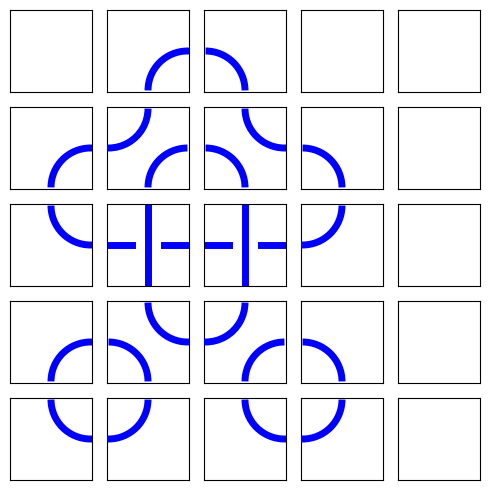

In [137]:
# mosaic = random_mosaic(dimension = 6, num_crossings=5); mosaic.show()
mosaic = Mosaic([[0,2,1,0,0],[2,8,7,1,0],[3,10,10,4,0],[2,7,8,1,0],[3,4,3,4,0]]); 
mosaic.show()

In [143]:
M = mosaic.matrixRepresentation; M

[ 0  2  1  0  0]
[ 2  8  7  1  0]
[ 3 10 10  4  0]
[ 2  7  8  1  0]
[ 3  4  3  4  0]

In [142]:
mosaic.strandMatrix()

[0 1 1 0 0]
[1 2 2 1 0]
[1 2 2 1 0]
[1 2 2 1 0]
[1 1 1 1 0]

In [ ]:
strand = mosaic.strandOf((1,0))

augmented_strandMatrix = mosaic.strandMatrix()

for tile in strand:
    augmented_strandMatrix[tile[0], tile[1]] -= 1 #decrease strand count by 1 for each tile in the strand

#augmented_strandMatrix

# sorted(L1) == sorted(L2) -- for later

def strands(mosaic):
    strands_list = []
    strandMatrix = mosaic.strandMatrix()
    while strandMatrix.nonzero_positions():
        start_tile = strandMatrix.nonzero_positions()[0]
        strand = mosaic.strandOf(start_tile)
        strands_list.append(strand)
        for tile in strand:
            strandMatrix[tile[0], tile[1]] -= 1
    return strands_list

testMatrix = mosaic.strandMatrix()
L = []
testMatrix.nonzero_positions()[0]
STRAND = mosaic.strandOf((3,0))
L.append(STRAND)
L
for tile in STRAND:
    testMatrix[tile[0], tile[1]] -= 1
testMatrix
testMatrix.nonzero_positions()[0]
STRAND = mosaic.strandOf((3,1)) # DIRECTION IS GONNA MATTER
L.append(STRAND)
L

#augmented_strandMatrix.nonzero_positions() # sage only

[[(4, 0), (4, 1), (3, 1), (3, 0)], [(3, 0), (4, 0), (4, 1), (3, 1)]]

In [25]:
len(mosaic.zoom().strandOf2((1,1),'left'))

48

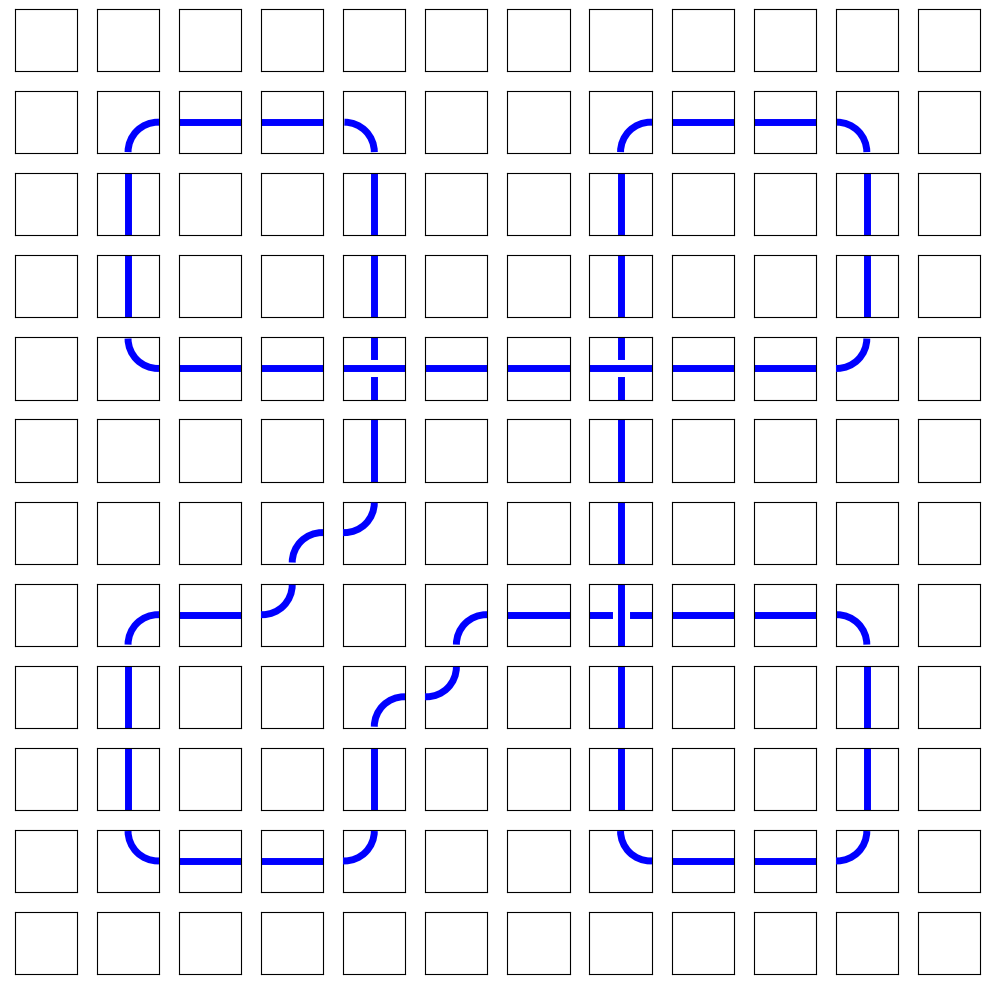

In [118]:
mosaic2 = mosaic.zoom(); mosaic2.show(10)

In [124]:
list(mosaic2.matrix())

[(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),
 (0, 2, 5, 5, 1, 0, 0, 2, 5, 5, 1, 0),
 (0, 6, 0, 0, 6, 0, 0, 6, 0, 0, 6, 0),
 (0, 6, 0, 0, 6, 0, 0, 6, 0, 0, 6, 0),
 (0, 3, 5, 5, 9, 5, 5, 9, 5, 5, 4, 0),
 (0, 0, 0, 0, 6, 0, 0, 6, 0, 0, 0, 0),
 (0, 0, 0, 2, 4, 0, 0, 6, 0, 0, 0, 0),
 (0, 2, 5, 4, 0, 2, 5, 10, 5, 5, 1, 0),
 (0, 6, 0, 0, 2, 4, 0, 6, 0, 0, 6, 0),
 (0, 6, 0, 0, 6, 0, 0, 6, 0, 0, 6, 0),
 (0, 3, 5, 5, 4, 0, 0, 3, 5, 5, 4, 0),
 (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)]

In [119]:
mosaic2.findCrossings()

[(4, 4), (4, 7), (7, 7)]

In [122]:
len(mosaic2.strandOf2((4,4)))

60

In [51]:
M = mosaic.matrix(); M

[ 0  2  1  0]
[ 2 10  8  1]
[ 3  9 10  4]
[ 0  3  4  0]

In [114]:
# if not given direction, choose random connection direction of tile
def strandOf2(self, tile, direction = choice(flatten(Tile(M[tile]).connectionDirections))):
    start_tile = tile
    start_direction = direction

    path = []

    tile, direction = self.exitPath(start_tile[0],start_tile[1],opposite(start_direction))
    path += [tile]

    # keeping track of initial direction deals with 2 strand tiles starting-points!
    while not (tile == start_tile and direction == start_direction):
        tile, direction = self.exitPath(tile[0],tile[1],opposite(direction))
        path += [tile]

    return path

In [90]:
start_tile = (0,1)
start_direction = 'left'

path = []

tile, direction = mosaic.exitPath(start_tile[0],start_tile[1],opposite(start_direction))
path += [tile]

# keeping track of initial direction deals with 2 strand tiles starting-points!
while not (tile == start_tile and direction == start_direction):
   tile, direction = mosaic.exitPath(tile[0],tile[1],opposite(direction))
   path += [tile]

len(path)

16

In [55]:
mosaic.exitPath(1,1,'left') #outputs tile you end up at and direction you exit from
mosaic.exitPath(1,2,opposite('right'))

[(0, 2), 'up']

In [56]:
mosaic.exitPath(1,2,opposite('right')) 

[(0, 2), 'up']

In [ ]:
while tile != (1,1):
    
    mosaic.exitPath(tile[0],tile[1],)

mosaic.exitPath(1,1,'left')

(1, 2)

In [43]:
mosaic.exitPath(1,2,'left')

(1, 3)

In [22]:
mosaic.shift(0,1, dictionary = True)

{'down': (1, 1), 'right': (0, 2)}

In [15]:
mosaic.findCrossings()

[(1, 1), (1, 2), (2, 1)]

In [7]:
mosaic.shift(0,1, True) # want [[lower1, lower2], [upper1, upper 2]]
# then need to figure out for the hyperbolic tiles

{'down': (1, 1), 'right': (0, 2)}

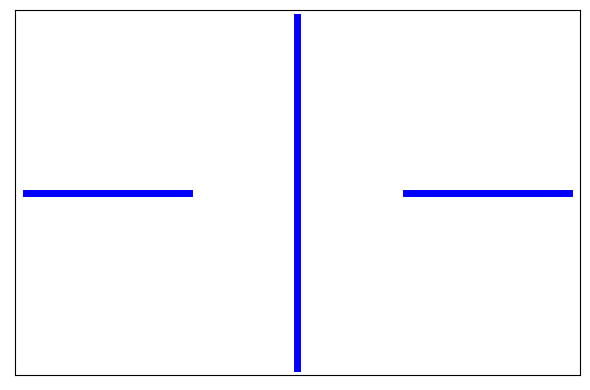

In [12]:
Tile(10).show()

In [42]:
Tile(7).connectionDirections

[['down', 'left'], ['up', 'right']]

In [ ]:
Mosaic()

In [ ]:
# for tile 7 want [[down, left], [up, right]]
# for tile 8 want [[down, right], [left, up]]
# for tile 9 want [[down, up], [left, right]], first always low strand
# for tile 10 want [[left, right], [up, down]]

# this is optional input for connection directions
# then implement into walk function
# then implmenet into strandof function

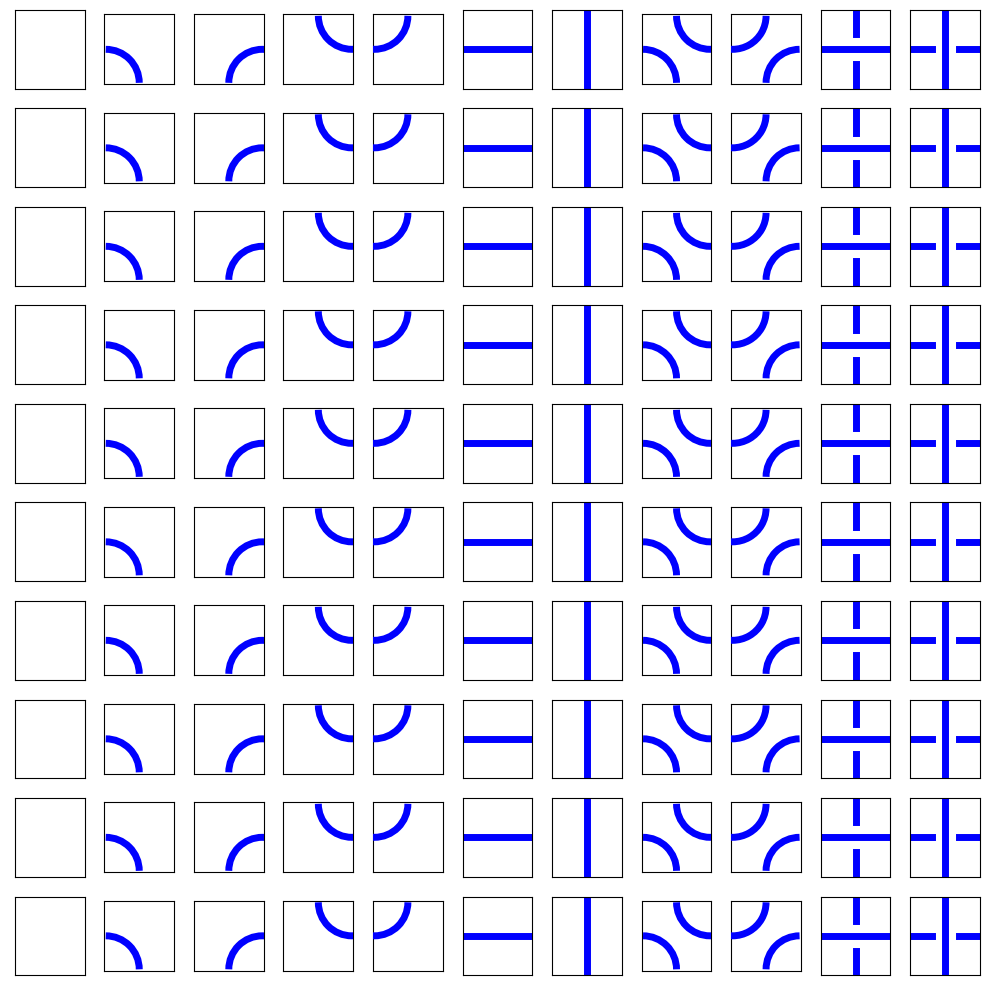

In [29]:
stupid = Mosaic([[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10],[0,1,2,3,4,5,6,7,8,9,10]]); stupid.show(10)